In this notebook I am going to try to replicate Figures 11 and 12 from Sadavoy, 2019 (https://ui.adsabs.harvard.edu/abs/2019ApJS..245....2S/abstract)

I am then going to try to adapt it to work for ALMA Band 5 and Band 7

## Load Intro Things

In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FITS FILES/BAND6/load_band6_data.py"

In [3]:
%run constants.py

In [4]:
color = ['red', 'blue', 'green']

ls = ['-', '--', '-.']

## Primary Beam and Centre Point

In [5]:
pb_path = band6_data_folder_path + "c2d_989_pbeam_233GHz.fits"

header, _, pb_map, wcs = read_in_file(pb_path)

ny, nx = pb_map.shape

In [6]:
flat_index = np.nanargmax(pb_map)   # ignores NaNs, finds max
y_cen, x_cen = np.unravel_index(flat_index, pb_map.shape)

print(rf'The centre position is: (y, x) = ({y_cen}, {x_cen}), and at this position pb = {pb_map[y_cen, x_cen]}')

The centre position is: (y, x) = (858, 861), and at this position pb = 1.0


In [7]:
dr_arcsec = 0.25
dr_deg = arcsec_to_degrees(dr_arcsec)

dr_pix = arcsec_to_pixels(header, dr_arcsec)

In [8]:
r_pix = np.arange(0, nx - x_cen, dr_pix)
r_arcsec = pixels_to_arcsec(header, r_pix)


df = pd.DataFrame({
    "r_pix": r_pix,
    "r_arcsec": r_arcsec,
    "r_deg": arcsec_to_degrees(r_arcsec)
})

In [9]:
x_pos = x_cen + r_pix.astype(int)

pb_val_arr = pb_map[y_cen, x_pos].astype(np.float32).newbyteorder('=')  # native endian
sigma_r_arr = (0.03 / pb_val_arr).astype(np.float32).newbyteorder('=')

df["pb_val"] = pb_val_arr
df["sigma_r"] = sigma_r_arr

df["area_annulus"] = 2 * np.pi * df["r_deg"] * dr_deg

In [10]:
def find_N_from_dN_dS(S_min):

    S_grid = np.logspace(-2, 2, 1000)  # 0.01 to 100 mJy

    # Compute dN/dS over flux grid
    dN_dS_grid = np.array([galaxy_probability(s, 'Band 6') for s in S_grid])

    # Select fluxes above threshold
    mask = S_grid >= S_min

    # Integrate using trapezoidal rule
    N_per_area = np.trapz(dN_dS_grid[mask], S_grid[mask])

    return N_per_area

In [11]:
# Dictionary to hold each df
df_sn_dict = {}

for sn in [5, 10, 20]:
    # Compute flux threshold per annulus
    S = sn * df["sigma_r"].values
    
    dN_dS = np.array([galaxy_probability(s, 'Band 6') for s in S])

    N_per_area_list = []

    # Loop over each annulus
    for S_min in S:
        # Use your function to integrate dN/dS above threshold
        N_per_area = find_N_from_dN_dS(S_min)
        N_per_area_list.append(N_per_area)

    N = np.array(N_per_area_list)

    # Multiply by annulus area to get expected number per annulus
    N_expected = N * df["area_annulus"].values
   
    prob = 100*(1 - np.exp(-N_expected))
    
    N_cumulative = np.cumsum(N_expected)
    prob_cumulative = 100 * (1 - np.exp(-N_cumulative))

    df_sn = pd.DataFrame({
        "r_arcsec": df["r_arcsec"].values,
        "S_mJy": S,
        "dN_dS": dN_dS,
        "N": N,
        "N_expected": N_expected,
        "prob": prob,
        "prob_cumulative": prob_cumulative
    })

    # Save in dictionary
    df_sn_dict[f"df_{sn}sigma"] = df_sn

# Access like:
df_5sigma = df_sn_dict["df_5sigma"]
df_10sigma = df_sn_dict["df_10sigma"]
df_20sigma = df_sn_dict["df_20sigma"]


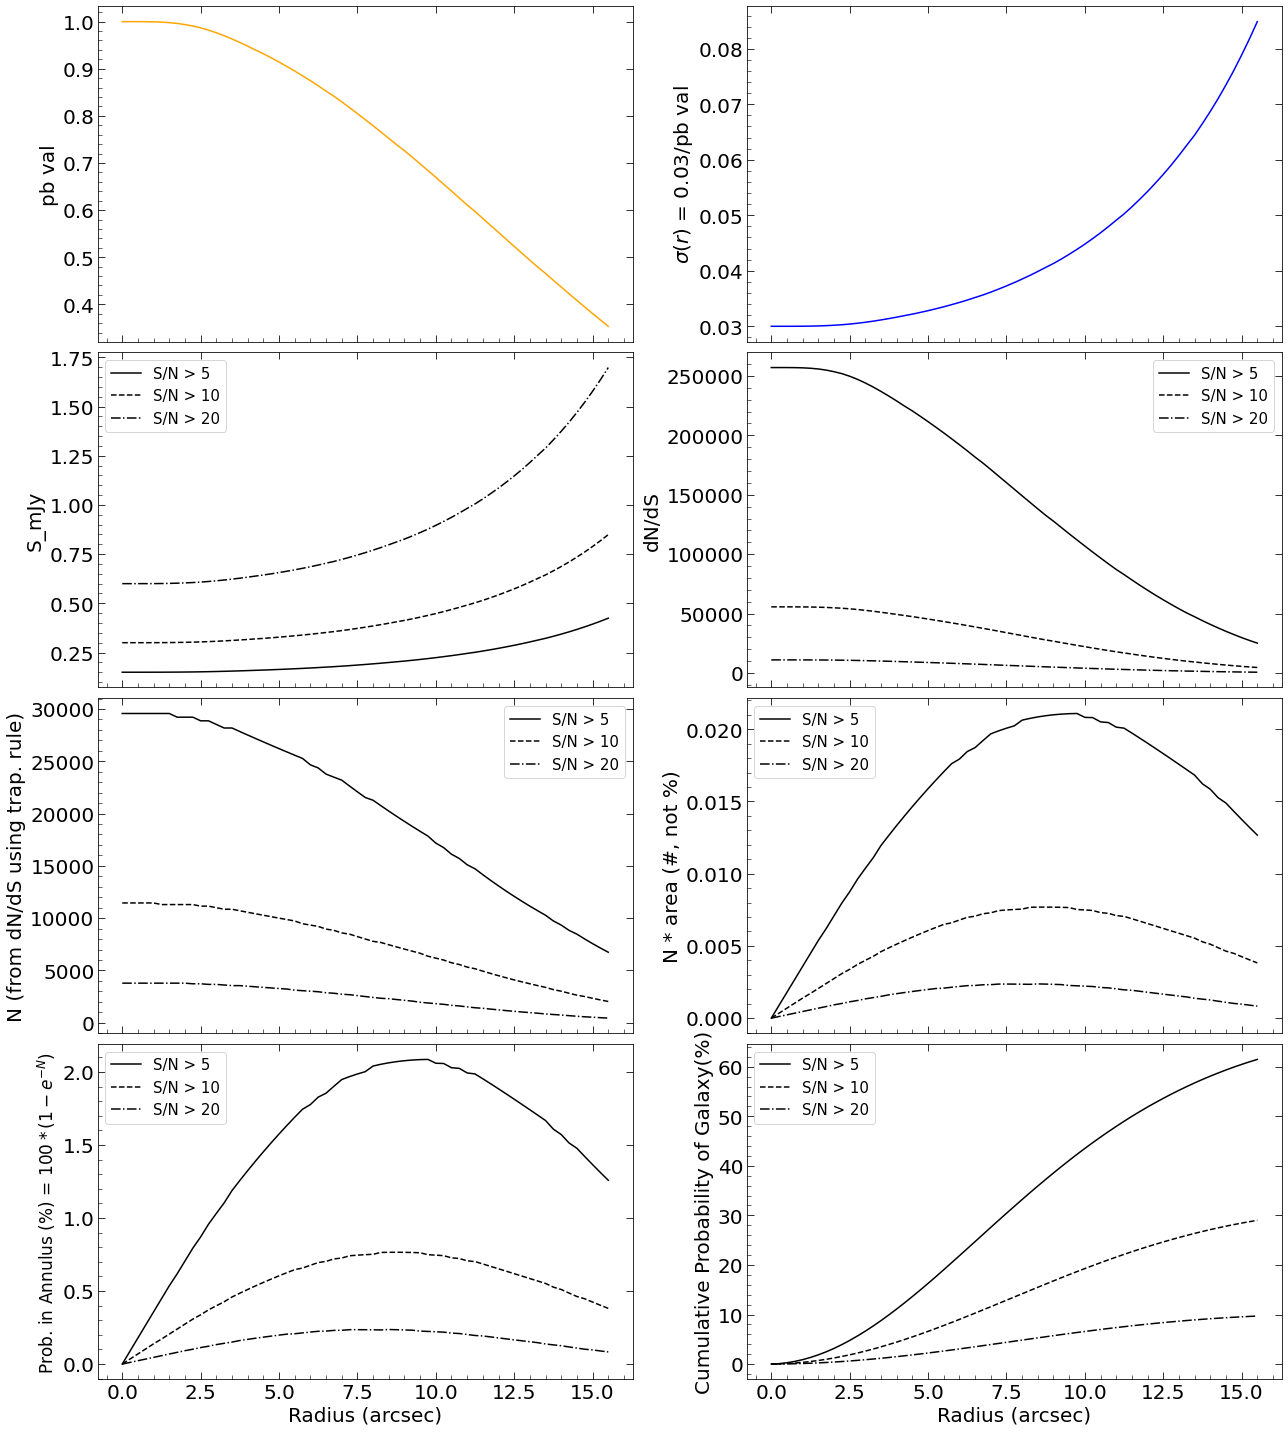

In [12]:
# ---------------------------
# Plot
# ---------------------------
fig, ax = plt.subplots(4, 2, figsize=(18, 20))


# Top left 
ax[0, 0].plot(df["r_arcsec"], df["pb_val"], color = 'orange')
ax[0, 0].set_ylabel('pb val', fontsize=axis_label_fs)


# Top right 
ax[0, 1].plot(df["r_arcsec"], df["sigma_r"], color = 'blue')
ax[0, 1].set_ylabel('$\sigma(r)$ = 0.03/pb val', fontsize=axis_label_fs)


# Top Middle left 
ax[1, 0].plot(df_5sigma["r_arcsec"],  df_5sigma["S_mJy"], color = 'black', ls = ls[0], label=f'S/N > 5')
ax[1, 0].plot(df_10sigma["r_arcsec"], df_10sigma["S_mJy"], color = 'black', ls = ls[1], label=f'S/N > 10')
ax[1, 0].plot(df_20sigma["r_arcsec"], df_20sigma["S_mJy"], color = 'black', ls = ls[2], label=f'S/N > 20')
ax[1, 0].set_ylabel('S_mJy', fontsize=axis_label_fs)
ax[1, 0].legend(fontsize = legend_text_fs)

# Top Middle Right
ax[1, 1].plot(df_5sigma["r_arcsec"], df_5sigma["dN_dS"], color = 'black', ls = ls[0], label=f'S/N > 5')
ax[1, 1].plot(df_10sigma["r_arcsec"], df_10sigma["dN_dS"], color = 'black', ls = ls[1], label=f'S/N > 10')
ax[1, 1].plot(df_20sigma["r_arcsec"], df_20sigma["dN_dS"], color = 'black', ls = ls[2], label=f'S/N > 20')
ax[1, 1].set_ylabel('dN/dS', fontsize=axis_label_fs)
ax[1, 1].legend(fontsize = legend_text_fs)


# Bottom Middle Left
ax[2, 0].plot(df_5sigma["r_arcsec"], df_5sigma["N"], color = 'black', ls = ls[0], label=f'S/N > 5')
ax[2, 0].plot(df_10sigma["r_arcsec"], df_10sigma["N"], color = 'black', ls = ls[1], label=f'S/N > 10')
ax[2, 0].plot(df_20sigma["r_arcsec"], df_20sigma["N"], color = 'black', ls = ls[2], label=f'S/N > 20')
ax[2, 0].set_ylabel('N (from dN/dS using trap. rule)', fontsize=axis_label_fs)
ax[2, 0].legend(fontsize = legend_text_fs)

# Bottom Middle Right
ax[2, 1].plot(df_5sigma["r_arcsec"], df_5sigma["N_expected"], color = 'black', ls = ls[0], label=f'S/N > 5')
ax[2, 1].plot(df_10sigma["r_arcsec"], df_10sigma["N_expected"], color = 'black', ls = ls[1], label=f'S/N > 10')
ax[2, 1].plot(df_20sigma["r_arcsec"], df_20sigma["N_expected"], color = 'black', ls = ls[2], label=f'S/N > 20')
ax[2, 1].set_ylabel('N * area (#, not %)', fontsize=axis_label_fs)
ax[2, 1].legend(fontsize = legend_text_fs)

# Bottom Left
ax[3, 0].plot(df_5sigma["r_arcsec"], df_5sigma["prob"], color = 'black', ls = ls[0], label=f'S/N > 5')
ax[3, 0].plot(df_10sigma["r_arcsec"], df_10sigma["prob"], color = 'black', ls = ls[1], label=f'S/N > 10')
ax[3, 0].plot(df_20sigma["r_arcsec"], df_20sigma["prob"], color = 'black', ls = ls[2], label=f'S/N > 20')
ax[3, 0].set_ylabel('Prob. in Annulus (%) = $100 * (1 - e^{-N})$', fontsize=axis_label_fs - 3)
ax[3, 0].legend(fontsize = legend_text_fs)

# peaks = [9.3, 8.8, 7]
# color = ['red', 'blue', 'green']

# for i in range(3):
#     ax[3, 0].axvline(peaks[i], color = color[i], ls = ls[i])
    
    
    
# Bottom Right
ax[3, 1].plot(df_5sigma["r_arcsec"], df_5sigma["prob_cumulative"], color = 'black', ls = ls[0], label=f'S/N > 5')
ax[3, 1].plot(df_10sigma["r_arcsec"], df_10sigma["prob_cumulative"], color = 'black', ls = ls[1], label=f'S/N > 10')
ax[3, 1].plot(df_20sigma["r_arcsec"], df_20sigma["prob_cumulative"], color = 'black', ls = ls[2], label=f'S/N > 20')
ax[3, 1].set_ylabel('Cumulative Probability of Galaxy(%)', fontsize=axis_label_fs)
ax[3, 1].legend(fontsize = legend_text_fs)

for i in range(3):
    for j in range(2):
        ax[i, j].tick_params(labelbottom=False)  # hide x-axis numbers
        
ax[3, 0].set_xlabel('Radius (arcsec)', fontsize=axis_label_fs)
ax[3, 1].set_xlabel('Radius (arcsec)', fontsize=axis_label_fs)   
    
for i in range(4):
    for j in range(2):
        ax[i, j].minorticks_on()
        ax[i, j].tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
        ax[i, j].tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)
        ax[i, j].tick_params(which='minor', length=4, direction="in")

fig.subplots_adjust(
    left=0.08,   # space on left
    right=0.95,  # space on right
    bottom=0.10, # space on bottom
    top=0.92,    # space on top
    wspace=0.25, # horizontal space between subplots
    hspace=-0.50  # vertical space between subplots
)

plt.tight_layout()
plt.show()

In [13]:
df_5sigma

,r_arcsec,S_mJy,dN_dS,N,N_expected,prob,prob_cumulative
0,0.00,0.150000,257049.283421,29569.025692,0.000000,0.000000,0.000000
1,0.25,0.150000,257048.619017,29569.025692,0.000896,0.089557,0.089557
2,0.50,0.150004,257036.106541,29569.025692,0.001792,0.179033,0.268429
3,0.75,0.150020,256976.379881,29569.025692,0.002688,0.268429,0.536138
4,1.00,0.150064,256810.258021,29569.025692,0.003584,0.357745,0.891965
...,...,...,...,...,...,...,...
58,14.50,0.367476,35079.483952,8471.816468,0.014889,1.477850,59.343990
59,14.75,0.380457,32387.490673,8008.074386,0.014316,1.421445,59.921893
60,15.00,0.394373,29810.513894,7566.112775,0.013756,1.366141,60.469416
61,15.25,0.408978,27402.555156,7145.039620,0.013207,1.311973,60.988046


In [14]:
# fig, ax = plt.subplots(1, 2, figsize=(20, 7))


# for i, N in enumerate(sn_levels):
#     # Annular detection probability
#     ax[0].plot(df["r_arcsec"][:-1], prob_band6_norm[i], color='black', ls=ls[i], label=f'S/N > {N}')
    
#     # Cumulative probability
#     ax[1].plot(df["r_arcsec"][:-1], prob_band6_cumulative[i], color='black', ls=ls[i], label=f'S/N > {N}')


# ax[0].set_ylabel('Probability of Galaxy in Annulus (%)', fontsize = axis_label_fs)
# ax[1].set_ylabel('Cumulative Probability of Galaxy(%)',  fontsize = axis_label_fs)


# for i in range(2):
    
#     # Add axis labels
#     ax[i].set_xlabel(r'Radius (arcsec)', fontsize=axis_label_fs)


#     # Adjust ticks
#     ax[i].minorticks_on()
#     ax[i].tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
#     ax[i].tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)
    
#     ax[i].legend(fontsize = legend_text_fs)

# # Mark the peak probability to see if it lines up with the paper
# peaks = [9.3, 8.8, 7]
# color = ['red', 'blue', 'green']

# for i in range(3):
#     ax[0].axvline(peaks[i], color = color[i], ls = ls[i])
    

In [15]:
# # Define a flux grid for integration (mJy)
# S_grid = np.logspace(-2, 2, 1000)  # from 0.01 to 100 mJy

# # Dictionary to hold dataframes for each S/N threshold
# df_sn_dict = {}

# # Loop over S/N thresholds
# for sn in [5, 10, 20]:
#     # Detection threshold per annulus
#     S_thresh = sn * df["sigma_r"].values

#     N_expected = []
#     N_per_area = []
#     dN_dS_thresh_list = []  # dN/dS evaluated exactly at threshold

#     # Loop over each annulus
#     for i, S_min in enumerate(S_thresh):
#         # Compute dN/dS exactly at threshold
#         dN_dS_thresh = galaxy_probability(S_min, 'Band 6')
#         dN_dS_thresh_list.append(dN_dS_thresh)

#         # Compute full dN/dS over flux grid
#         dN_dS_grid = np.array([galaxy_probability(s, 'Band 6') for s in S_grid])

#         # Select fluxes above threshold
#         mask = S_grid >= S_min

#         # Integrate using trapezoidal rule to get number per deg²
#         N_int_per_area = np.trapz(dN_dS_grid[mask], S_grid[mask])
#         N_per_area.append(N_int_per_area)

#         # Multiply by annulus area to get total expected number in annulus
#         N_expected.append(N_int_per_area * df["area_annulus"].values[i])

#     # Convert to arrays
#     N_expected = np.array(N_expected)
#     N_per_area = np.array(N_per_area)
#     dN_dS_thresh_list = np.array(dN_dS_thresh_list)

#     # Compute probabilities
#     prob = 1 - np.exp(-N_expected)                     # per-annulus probability
#     prob_cumulative = 100 * (1 - np.exp(-np.cumsum(N_expected)))  # cumulative probability

#     # Build dataframe
#     df_sn = pd.DataFrame({
#         "r_arcsec": df["r_arcsec"].values,
#         "area_deg2": df["area_annulus"].values,
#         "S_mJy": S_thresh,
#         "dN_dS": dN_dS_thresh_list,  # exact dN/dS at threshold
#         "N_per_area": N_per_area,           # integrated number per deg²
#         "N_expected": N_expected,           # expected number in annulus
#         "prob": prob,                       # per-annulus probability
#         "prob_cumulative": prob_cumulative  # cumulative probability
#     })

#     # Save in dictionary keyed by S/N
#     df_sn_dict[f"df_{sn}sigma"] = df_sn

# # Access like:
# df_5sigma = df_sn_dict["df_5sigma"]
# df_10sigma = df_sn_dict["df_10sigma"]
# df_20sigma = df_sn_dict["df_20sigma"]


In [16]:
# # Dictionary to hold each df
# df_sn_dict = {}

# for sn in [5, 10, 20]:
#     S = sn * df["sigma_r"].values
#     dN_dS = np.array([galaxy_probability(s, 'Band 6') for s in S])
    
#     # Use trapezoid to find N from dN/dS
#     N_per_area = find_N_from_dN_dS(dN_dS)
    
#     # Find N expected by multiplying by area
#     N_expected = N_per_area * df["area_annulus"].values
    
    
#     prob = (1 - np.exp(-N_expected))
    
#     N_cumulative = np.cumsum(N_expected)
#     prob_cumulative = 100 * (1 - np.exp(-N_cumulative))

#     df_sn = pd.DataFrame({
#         "r_arcsec": df["r_arcsec"].values,
#         "area": df["area_annulus"].values,
#         "S_mJy": S,
#         "dN_dS": dN_dS,
#         "N_per_area": N_per_area,
#         "N_expected": N_expected * 100,
#         "prob": prob,
#         "prob_cumulative": prob_cumulative
#     })

#     # Save in dictionary
#     df_sn_dict[f"df_{sn}sigma"] = df_sn

# # Access like:
# df_5sigma = df_sn_dict["df_5sigma"]
# df_10sigma = df_sn_dict["df_10sigma"]
# df_20sigma = df_sn_dict["df_20sigma"]
